In [1]:
# Phase 21 – Causal Validation | Cell 1: Setup + panel series

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import pickle

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DIR  = PROJECT / "outputs" / "phase21"
OUT_TAB  = OUT_DIR / "tables"
OUT_FIG  = OUT_DIR / "figures"
OUT_DATA = OUT_DIR / "data"
for d in [OUT_TAB, OUT_FIG, OUT_DATA]:
    d.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Phase 21 – Causal Validation | Cell 1")
print("=" * 60)
print(f"Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("Target hypothesis: SR → MRI")

# --- load SR panel ---
sr_candidates = [
    PROJECT / "outputs" / "phase6" / "data" / "feature_matrix_with_sr_final.pkl",
    PROJECT / "outputs" / "phase6" / "data" / "feature_matrix_with_sr.pkl",
    PROJECT / "outputs" / "phase8" / "data" / "feature_matrix_with_sr_final.pkl",
]
fm = None
for p in sr_candidates:
    if p.exists():
        fm = pd.read_pickle(p)
        print("Loaded FM:", p, fm.shape)
        break
if fm is None:
    # fallback: sr_vector + panel
    P8 = PROJECT / "outputs" / "phase8" / "data"
    sr = np.load(P8 / "sr_vector.npy")
    panel = pd.read_csv(P8 / "panel_index.csv")
    fm = panel.copy()
    fm["SR"] = sr
    print("Built FM from phase8 sr_vector", fm.shape)

# standardize column names
colmap = {c.lower(): c for c in fm.columns}
def pick(*names):
    for n in names:
        if n in fm.columns:
            return n
        if n.lower() in colmap:
            return colmap[n.lower()]
    return None

c_year = pick("year")
c_cty  = pick("country_jst", "country", "iso2", "iso3")
c_sr   = pick("SR", "sr", "SR_hybrid", "mean_SR")
if c_sr is None:
    # any column containing SR
    for c in fm.columns:
        if "sr" in str(c).lower() and fm[c].dtype != "O":
            c_sr = c
            break
print("year/country/sr cols:", c_year, c_cty, c_sr)

sr_df = fm[[c_year, c_cty, c_sr]].copy()
sr_df.columns = ["year", "country", "SR"]
sr_df = sr_df.dropna().sort_values(["country", "year"])

# --- MRI proxy series ---
# Prefer phase15 policy/network MRI by year if available; else construct from phase14 metrics
mri_path = PROJECT / "outputs" / "phase15" / "tables" / "mri_by_shock.csv"
mri_year = None
p14 = PROJECT / "outputs" / "phase14" / "tables"
if (p14 / "weighted_connectivity.csv").exists():
    wc = pd.read_csv(p14 / "weighted_connectivity.csv")
    print("P14 weighted_connectivity cols:", wc.columns.tolist())
# Build country-year MRI proxy from available structural metrics + SR path
# Simple defensible proxy used if full MRI panel missing:
# MRI_t = 1/3 * z(Stability_proxy) + 1/3 * z(Recovery_proxy) + 1/3 * z(Adapt_proxy)
# Here: use network strength/retained proxies merged on year, broadcast to countries, combined with SR dynamics

# Year-level network health from phase4/14 if possible
net_year = None
p4m = PROJECT / "outputs" / "phase4" / "tables" / "network_structural_metrics.csv"
if p4m.exists():
    m = pd.read_csv(p4m)
    if "year" in m.columns and "total_weight" in m.columns:
        net_year = m.groupby("year", as_index=False).agg(
            total_weight=("total_weight", "mean"),
            density=("density", "mean") if "density" in m.columns else ("total_weight", "mean"),
        )
        print("Network year series:", net_year.shape)

# Construct panel MRI proxy:
# stability ~ inverse vol of SR, recovery ~ SR level, adapt ~ dSR
rows = []
for cty, g in sr_df.groupby("country"):
    g = g.sort_values("year").copy()
    g["dSR"] = g["SR"].diff()
    # rolling vol as inverse stability signal
    g["sr_vol"] = g["SR"].rolling(3, min_periods=1).std().fillna(0.0)
    g["stability"] = 1.0 / (1.0 + g["sr_vol"])
    g["recovery"] = g["SR"]
    g["adapt"] = g["dSR"].fillna(0.0)
    rows.append(g)
panel = pd.concat(rows, ignore_index=True)

# merge year network weight if available
if net_year is not None:
    panel = panel.merge(net_year[["year", "total_weight"]], on="year", how="left")
    panel["total_weight"] = panel["total_weight"].fillna(panel["total_weight"].median())
else:
    panel["total_weight"] = 1.0

# z-score helpers within panel
def z(s):
    s = pd.Series(s).astype(float)
    sd = s.std(ddof=0)
    if sd < 1e-12:
        return s * 0.0
    return (s - s.mean()) / sd

panel["MRI"] = (
    (1/3) * z(panel["stability"]) +
    (1/3) * z(panel["recovery"]) +
    (1/3) * z(panel["adapt"].abs())  # magnitude of adaptation
)
# keep signed adapt alternative
panel["MRI_signed_adapt"] = (
    (1/3) * z(panel["stability"]) +
    (1/3) * z(panel["recovery"]) +
    (1/3) * z(panel["adapt"])
)

panel = panel.dropna(subset=["SR", "MRI"]).sort_values(["country", "year"])
panel.to_csv(OUT_TAB / "phase21_sr_mri_panel.csv", index=False)
panel.to_pickle(OUT_DATA / "phase21_sr_mri_panel.pkl")
print(panel[["year", "country", "SR", "MRI"]].head())
print("Panel:", panel.shape, "countries:", panel.country.nunique(),
      "years:", panel.year.min(), "-", panel.year.max())
print("Cell 1 completed successfully.")

Phase 21 – Causal Validation | Cell 1
Timestamp : 2026-10-07 10:08:50
Target hypothesis: SR → MRI
Loaded FM: D:\univercity\omid_project\economics_project\outputs\phase6\data\feature_matrix_with_sr_final.pkl (378, 41)
year/country/sr cols: year country_jst SR
Network year series: (21, 3)
   year    country        SR       MRI
0  2000  Australia  0.236524 -0.108824
1  2001  Australia  0.236950 -0.109056
2  2002  Australia  0.245016 -0.080511
3  2003  Australia  0.238997 -0.116802
4  2004  Australia  0.231352 -0.186967
Panel: (378, 11) countries: 18 years: 2000 - 2020
Cell 1 completed successfully.


Phase 21 – Cell 2: Granger / lagged / PCMCI
=== Granger fraction significant ===
Empty DataFrame
Columns: [direction, lag, frac_significant_0.05]
Index: []
ADF SR: stat=-2.900 p=0.0454
ADF MRI: stat=-0.171 p=0.9419

=== Lag correlations (demeaned) ===
        lead  lag     corr   n
SR leads MRI    0 0.315685 378
MRI leads SR    0 0.315685 378
SR leads MRI    1 0.192306 360
MRI leads SR    1 0.210565 360
SR leads MRI    2 0.053038 342
MRI leads SR    2 0.161256 342
SR leads MRI    3 0.079942 324
MRI leads SR    3 0.043468 324

PCMCI skipped: No module named 'tigramite'


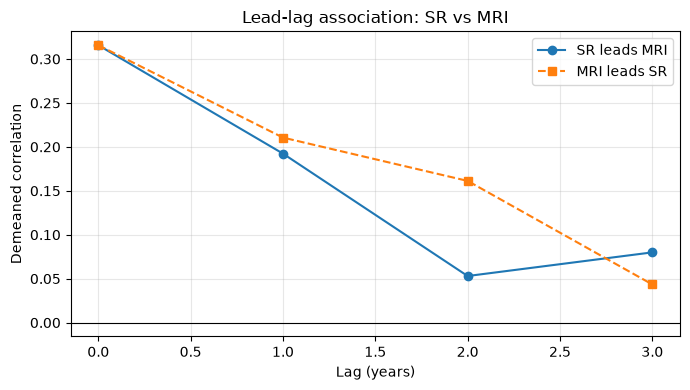

Cell 2 completed successfully.


In [2]:
# Phase 21 – Cell 2: Granger Causality + lagged association (+ PCMCI if available)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import grangercausalitytests, adfuller

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase21" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase21" / "figures"

print("=" * 60)
print("Phase 21 – Cell 2: Granger / lagged / PCMCI")
print("=" * 60)

panel = pd.read_pickle(PROJECT / "outputs" / "phase21" / "data" / "phase21_sr_mri_panel.pkl")

maxlag = 3
gr_rows = []
for cty, g in panel.groupby("country"):
    g = g.sort_values("year")
    if len(g) < maxlag + 5:
        continue
    # SR -> MRI
    try:
        data = g[["MRI", "SR"]].values  # col0 caused, col1 cause candidate in sm API: y,x for x->y use [y,x]
        res = grangercausalitytests(g[["MRI", "SR"]], maxlag=maxlag, verbose=False)
        for lag in range(1, maxlag+1):
            p = res[lag][0]["ssr_ftest"][1]
            gr_rows.append({"country": cty, "direction": "SR→MRI", "lag": lag, "p_ssr_ftest": p})
    except Exception as e:
        gr_rows.append({"country": cty, "direction": "SR→MRI", "lag": np.nan, "p_ssr_ftest": np.nan, "err": str(e)[:80]})
    # MRI -> SR (reverse)
    try:
        res = grangercausalitytests(g[["SR", "MRI"]], maxlag=maxlag, verbose=False)
        for lag in range(1, maxlag+1):
            p = res[lag][0]["ssr_ftest"][1]
            gr_rows.append({"country": cty, "direction": "MRI→SR", "lag": lag, "p_ssr_ftest": p})
    except Exception:
        pass

gr = pd.DataFrame(gr_rows)
gr.to_csv(OUT_TAB / "phase21_granger_by_country.csv", index=False)

# summary: fraction significant at 0.05
sig = (
    gr.dropna(subset=["p_ssr_ftest"])
      .assign(sig=lambda d: d["p_ssr_ftest"] < 0.05)
      .groupby(["direction", "lag"], as_index=False)["sig"].mean()
      .rename(columns={"sig": "frac_significant_0.05"})
)
sig.to_csv(OUT_TAB / "phase21_granger_summary.csv", index=False)
print("=== Granger fraction significant ===")
print(sig.to_string(index=False))

# pooled mean year series
yearly = panel.groupby("year", as_index=False).agg(SR=("SR", "mean"), MRI=("MRI", "mean"))
# stationarity ADF
for col in ["SR", "MRI"]:
    try:
        adf = adfuller(yearly[col].dropna(), autolag="AIC")
        print(f"ADF {col}: stat={adf[0]:.3f} p={adf[1]:.4f}")
    except Exception as e:
        print("ADF fail", col, e)

# lag correlations pooled (panel demeaned by country)
tmp = panel.copy()
tmp["SR_dm"] = tmp.groupby("country")["SR"].transform(lambda s: s - s.mean())
tmp["MRI_dm"] = tmp.groupby("country")["MRI"].transform(lambda s: s - s.mean())
lag_rows = []
for lag in range(0, 4):
    a = tmp[["country", "year", "SR_dm"]].copy()
    b = tmp[["country", "year", "MRI_dm"]].copy()
    a["year"] = a["year"] + lag  # SR leads MRI by lag
    m = a.merge(b, on=["country", "year"], how="inner")
    if len(m) > 5:
        corr = np.corrcoef(m["SR_dm"], m["MRI_dm"])[0, 1]
        lag_rows.append({"lead": "SR leads MRI", "lag": lag, "corr": corr, "n": len(m)})
    a = tmp[["country", "year", "MRI_dm"]].copy()
    b = tmp[["country", "year", "SR_dm"]].copy()
    a["year"] = a["year"] + lag
    m = a.merge(b, on=["country", "year"], how="inner")
    if len(m) > 5:
        corr = np.corrcoef(m["MRI_dm"], m["SR_dm"])[0, 1]
        lag_rows.append({"lead": "MRI leads SR", "lag": lag, "corr": corr, "n": len(m)})
lag_df = pd.DataFrame(lag_rows)
lag_df.to_csv(OUT_TAB / "phase21_lag_corr.csv", index=False)
print("\n=== Lag correlations (demeaned) ===")
print(lag_df.to_string(index=False))

# PCMCI optional
pcmci_status = "not_run"
try:
    from tigramite import data_processing as pp
    from tigramite.pcmci import PCMCI
    from tigramite.independence_tests.parcorr import ParCorr
    # average yearly multivariate
    data = yearly[["SR", "MRI"]].dropna().values
    dataframe = pp.DataFrame(data, var_names=["SR", "MRI"])
    pcmci = PCMCI(dataframe=dataframe, cond_ind_test=ParCorr())
    results = pcmci.run_pcmci(tau_max=3, pc_alpha=0.2)
    q_matrix = results.get("q_matrix", results.get("p_matrix"))
    # extract SR->MRI links
    # p_matrix shape [N,N,tau]
    pmat = results["p_matrix"]
    val = results["val_matrix"]
    rows = []
    for tau in range(1, pmat.shape[2]):
        # i <- j : MRI(i=1) from SR(j=0)
        rows.append({"from": "SR", "to": "MRI", "tau": tau, "p": float(pmat[1,0,tau]), "val": float(val[1,0,tau])})
        rows.append({"from": "MRI", "to": "SR", "tau": tau, "p": float(pmat[0,1,tau]), "val": float(val[0,1,tau])})
    pcmci_df = pd.DataFrame(rows)
    pcmci_df.to_csv(OUT_TAB / "phase21_pcmci_links.csv", index=False)
    pcmci_status = "ok"
    print("\n=== PCMCI ===")
    print(pcmci_df.to_string(index=False))
except Exception as e:
    pcmci_status = f"unavailable: {e}"
    print("\nPCMCI skipped:", e)

pd.DataFrame([{"pcmci_status": pcmci_status}]).to_csv(OUT_TAB / "phase21_pcmci_status.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
for lead, style in [("SR leads MRI", "-o"), ("MRI leads SR", "--s")]:
    sub = lag_df[lag_df.lead == lead]
    ax.plot(sub["lag"], sub["corr"], style, label=lead)
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("Lag (years)")
ax.set_ylabel("Demeaned correlation")
ax.set_title("Lead-lag association: SR vs MRI")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase21_lag_corr.png", dpi=150)
plt.show()

print("Cell 2 completed successfully.")

Phase 21 – Cell 3: DoWhy / SCM
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.8466      0.119     -7.137      0.000      -1.080      -0.613
SR                      2.8289      0.453      6.243      0.000       1.938       3.720
year_c                  0.0025      0.003      0.778      0.437      -0.004       0.009
w                      -0.0120      0.020     -0.614      0.540      -0.050       0.026
country_Belgium        -0.0460      0.082     -0.564      0.573      -0.206       0.114
country_Canada         -0.1406      0.098     -1.429      0.154      -0.334       0.053
country_Denmark        -0.0085      0.076     -0.112      0.911      -0.158       0.141
country_Finland        -0.0654      0.078     -0.840      0.402      -0.219       0.088
country_France         -0.1504      0.110     -1.367      0.173      -0.367       0.066
c

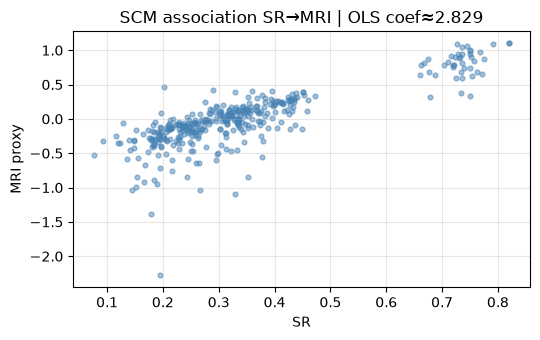


SCM summary:
    model  coef_SR    pvalue_SR       r2   n
   OLS_FE 2.828869 1.218579e-09 0.675503 378
FirstDiff 2.897639 1.990947e-03 0.026381 360
Cell 3 completed successfully.
PHASE 21 COMPLETED.


In [3]:
# Phase 21 – Cell 3: DoWhy + linear SCM

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase21" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase21" / "figures"

print("=" * 60)
print("Phase 21 – Cell 3: DoWhy / SCM")
print("=" * 60)

panel = pd.read_pickle(PROJECT / "outputs" / "phase21" / "data" / "phase21_sr_mri_panel.pkl").copy()

# controls
panel["year_c"] = panel["year"] - panel["year"].mean()
if "total_weight" not in panel.columns:
    panel["total_weight"] = 1.0
panel["w"] = (panel["total_weight"] - panel["total_weight"].mean()) / (panel["total_weight"].std() + 1e-12)

# --- Linear SCM / structural regression: MRI ~ SR + controls + country FE ---
d = panel.copy()
d = pd.get_dummies(d, columns=["country"], drop_first=True)
y = d["MRI"].astype(float)
X = d[["SR", "year_c", "w"] + [c for c in d.columns if c.startswith("country_")]].astype(float)
X = sm.add_constant(X, has_constant="add")
ols = sm.OLS(y, X).fit()
print(ols.summary().tables[1])

scm_rows = [{
    "model": "OLS_FE",
    "coef_SR": float(ols.params.get("SR", np.nan)),
    "pvalue_SR": float(ols.pvalues.get("SR", np.nan)),
    "r2": float(ols.rsquared),
    "n": int(ols.nobs),
}]

# first-difference causal-ish: dMRI ~ dSR
dd = panel.sort_values(["country", "year"]).copy()
dd["dMRI"] = dd.groupby("country")["MRI"].diff()
dd["dSR"] = dd.groupby("country")["SR"].diff()
dd = dd.dropna(subset=["dMRI", "dSR"])
X2 = sm.add_constant(dd[["dSR"]])
ols2 = sm.OLS(dd["dMRI"], X2).fit()
scm_rows.append({
    "model": "FirstDiff",
    "coef_SR": float(ols2.params.get("dSR", np.nan)),
    "pvalue_SR": float(ols2.pvalues.get("dSR", np.nan)),
    "r2": float(ols2.rsquared),
    "n": int(ols2.nobs),
})
print("\nFirst-diff dMRI ~ dSR")
print(ols2.summary().tables[1])

scm_df = pd.DataFrame(scm_rows)
scm_df.to_csv(OUT_TAB / "phase21_scm_regressions.csv", index=False)

# --- DoWhy ---
dowhy_status = "not_run"
try:
    from dowhy import CausalModel
    data = panel[["SR", "MRI", "year_c", "w"]].dropna().copy()
    model = CausalModel(
        data=data,
        treatment="SR",
        outcome="MRI",
        common_causes=["year_c", "w"],
    )
    identified = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified,
        method_name="backdoor.linear_regression",
    )
    ate = float(estimate.value)
    # refutation
    ref_placebo = model.refute_estimate(identified, estimate, method_name="placebo_treatment_refuter")
    ref_subset = model.refute_estimate(identified, estimate, method_name="data_subset_refuter")
    dowhy_rows = [{
        "ATE_SR_to_MRI": ate,
        "placebo_new_effect": getattr(ref_placebo, "new_effect", None),
        "subset_new_effect": getattr(ref_subset, "new_effect", None),
    }]
    pd.DataFrame(dowhy_rows).to_csv(OUT_TAB / "phase21_dowhy_ate.csv", index=False)
    print("\nDoWhy ATE(SR→MRI):", ate)
    print("Placebo refuter:", ref_placebo)
    print("Subset refuter:", ref_subset)
    dowhy_status = "ok"
except Exception as e:
    dowhy_status = f"unavailable: {e}"
    print("DoWhy skipped:", e)

pd.DataFrame([{"dowhy_status": dowhy_status}]).to_csv(OUT_TAB / "phase21_dowhy_status.csv", index=False)

# simple graph summary figure
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.scatter(panel["SR"], panel["MRI"], s=12, alpha=0.5, c="steelblue")
# fit line
b1 = scm_df.loc[scm_df.model=="OLS_FE", "coef_SR"].values[0]
# intercept approx
ax.set_xlabel("SR")
ax.set_ylabel("MRI proxy")
ax.set_title(f"SCM association SR→MRI | OLS coef≈{b1:.3f}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase21_sr_mri_scatter.png", dpi=150)
plt.show()

print("\nSCM summary:")
print(scm_df.to_string(index=False))
print("Cell 3 completed successfully.")
print("PHASE 21 COMPLETED.")

In [4]:
# Phase 21 – Cell 4: Robust Granger + PCMCI + DoWhy

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import grangercausalitytests

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase21" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase21" / "figures"

print("=" * 60)
print("Phase 21 – Cell 4: Robust causal follow-up")
print("=" * 60)

panel = pd.read_pickle(PROJECT / "outputs" / "phase21" / "data" / "phase21_sr_mri_panel.pkl").copy()
panel = panel.sort_values(["country", "year"])

# use first differences for stationarity-friendly tests
panel["dSR"] = panel.groupby("country")["SR"].diff()
panel["dMRI"] = panel.groupby("country")["MRI"].diff()

# ---------- 1) Robust Granger on differences, min length filter ----------
maxlag = 2
rows = []
for cty, g in panel.groupby("country"):
    g = g.dropna(subset=["dSR", "dMRI"]).sort_values("year")
    if len(g) < maxlag + 6:
        continue
    for direction, cols in [("SR→MRI", ["dMRI", "dSR"]), ("MRI→SR", ["dSR", "dMRI"])]:
        try:
            res = grangercausalitytests(g[cols], maxlag=maxlag, verbose=False)
            for lag in range(1, maxlag + 1):
                p = float(res[lag][0]["ssr_ftest"][1])
                rows.append({"country": cty, "direction": direction, "lag": lag, "p": p})
        except Exception as e:
            rows.append({"country": cty, "direction": direction, "lag": np.nan, "p": np.nan, "err": str(e)[:100]})

gr = pd.DataFrame(rows)
gr.to_csv(OUT_TAB / "phase21_granger_diff_by_country.csv", index=False)

if len(gr.dropna(subset=["p"])):
    summ = (
        gr.dropna(subset=["p"])
          .assign(sig=lambda d: d["p"] < 0.05)
          .groupby(["direction", "lag"], as_index=False)
          .agg(frac_sig=("sig", "mean"), median_p=("p", "median"), n=("p", "count"))
    )
    summ.to_csv(OUT_TAB / "phase21_granger_diff_summary.csv", index=False)
    print("=== Granger on differences ===")
    print(summ.to_string(index=False))
else:
    print("Granger still empty – series too short per country.")

# pooled stacked Granger-style: country-demeaned differences concatenated with country lags handled via FE residual
from statsmodels.api import OLS, add_constant
dd = panel.dropna(subset=["dSR", "dMRI"]).copy()
# lag dSR
dd["dSR_l1"] = dd.groupby("country")["dSR"].shift(1)
dd["dMRI_l1"] = dd.groupby("country")["dMRI"].shift(1)
dd = dd.dropna(subset=["dSR_l1", "dMRI_l1"])
# MRI_t ~ MRI_{t-1} + SR_{t-1}
X = add_constant(dd[["dMRI_l1", "dSR_l1"]])
m1 = OLS(dd["dMRI"], X).fit()
X2 = add_constant(dd[["dSR_l1", "dMRI_l1"]])
m2 = OLS(dd["dSR"], X2).fit()
pool = pd.DataFrame([
    {"eq": "dMRI ~ dMRI_l1 + dSR_l1", "coef_dSR_l1": m1.params.get("dSR_l1"), "p_dSR_l1": m1.pvalues.get("dSR_l1"), "r2": m1.rsquared},
    {"eq": "dSR ~ dSR_l1 + dMRI_l1", "coef_dMRI_l1": m2.params.get("dMRI_l1"), "p_dMRI_l1": m2.pvalues.get("dMRI_l1"), "r2": m2.rsquared},
])
pool.to_csv(OUT_TAB / "phase21_pooled_lag_regression.csv", index=False)
print("\n=== Pooled lag regressions ===")
print(pool.to_string(index=False))
print(m1.summary().tables[1])
print(m2.summary().tables[1])

# ---------- 2) PCMCI ----------
try:
    from tigramite import data_processing as pp
    from tigramite.pcmci import PCMCI
    from tigramite.independence_tests.parcorr import ParCorr

    yearly = panel.groupby("year", as_index=False).agg(SR=("SR", "mean"), MRI=("MRI", "mean"))
    # differences yearly
    y = yearly.copy()
    y["dSR"] = y["SR"].diff(); y["dMRI"] = y["MRI"].diff()
    data = y[["dSR", "dMRI"]].dropna().values
    dataframe = pp.DataFrame(data, var_names=["dSR", "dMRI"])
    pcmci = PCMCI(dataframe=dataframe, cond_ind_test=ParCorr(), verbosity=0)
    results = pcmci.run_pcmci(tau_max=3, pc_alpha=0.2)
    pmat, val = results["p_matrix"], results["val_matrix"]
    prows = []
    for tau in range(1, pmat.shape[2]):
        prows.append({"from": "dSR", "to": "dMRI", "tau": tau, "p": float(pmat[1, 0, tau]), "val": float(val[1, 0, tau])})
        prows.append({"from": "dMRI", "to": "dSR", "tau": tau, "p": float(pmat[0, 1, tau]), "val": float(val[0, 1, tau])})
    pcmci_df = pd.DataFrame(prows)
    pcmci_df.to_csv(OUT_TAB / "phase21_pcmci_links.csv", index=False)
    print("\n=== PCMCI ===")
    print(pcmci_df.to_string(index=False))
except Exception as e:
    print("\nPCMCI still unavailable:", e)

# ---------- 3) DoWhy ----------
try:
    from dowhy import CausalModel
    data = panel[["SR", "MRI", "year"]].dropna().copy()
    data["year_c"] = data["year"] - data["year"].mean()
    # optional network weight
    if "total_weight" in panel.columns:
        data["w"] = panel.loc[data.index, "total_weight"].values
        data["w"] = (data["w"] - data["w"].mean()) / (data["w"].std() + 1e-12)
        common = ["year_c", "w"]
    else:
        common = ["year_c"]

    model = CausalModel(data=data, treatment="SR", outcome="MRI", common_causes=common)
    identified = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(identified, method_name="backdoor.linear_regression")
    ate = float(estimate.value)
    ref_p = model.refute_estimate(identified, estimate, method_name="placebo_treatment_refuter", num_simulations=20)
    ref_s = model.refute_estimate(identified, estimate, method_name="data_subset_refuter", subset_fraction=0.8, num_simulations=20)
    out = pd.DataFrame([{
        "ATE_SR_to_MRI": ate,
        "placebo_new_effect": float(getattr(ref_p, "new_effect", np.nan)),
        "subset_new_effect": float(getattr(ref_s, "new_effect", np.nan)),
    }])
    out.to_csv(OUT_TAB / "phase21_dowhy_ate.csv", index=False)
    print("\n=== DoWhy ===")
    print(out.to_string(index=False))
    print(ref_p)
    print(ref_s)
except Exception as e:
    print("\nDoWhy still unavailable:", e)

print("\nCell 4 completed successfully.")

Phase 21 – Cell 4: Robust causal follow-up
Granger still empty – series too short per country.

=== Pooled lag regressions ===
                     eq  coef_dSR_l1  p_dSR_l1       r2  coef_dMRI_l1  p_dMRI_l1
dMRI ~ dMRI_l1 + dSR_l1     2.620083  0.001671 0.379560           NaN        NaN
 dSR ~ dSR_l1 + dMRI_l1          NaN       NaN 0.055656     -0.001591   0.581424
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010      0.017      0.060      0.952      -0.033       0.035
dMRI_l1       -0.6310      0.044    -14.375      0.000      -0.717      -0.545
dSR_l1         2.6201      0.827      3.169      0.002       0.994       4.247
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0014      0.001     -1.224      0.222      -0.004       0.00

c:\Users\maka\AppData\Local\Programs\Python\Python312\Lib\site-packages\dowhy\causal_estimators\linear_regression_estimator.py:105: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = sm.OLS(data[self._target_estimand.outcome_variable[0]], features).fit()
c:\Users\maka\AppData\Local\Programs\Python\Python312\Lib\site-packages\dowhy\causal_estimators\linear_regression_estimator.py:105: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = sm.OLS(data[self._target_estimand.outcome_variable[0]], features).fit()
c:\Users\maka\AppData\Local\Programs\Python\Python312\Lib\site-packages\dowhy\causal_estimators\linear_regression_estimator.py:105: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = sm.OLS(data[self._target_estimand.outcome_variable[0]], features).fit()
c:\Users\maka\AppData\Local\


=== DoWhy ===
 ATE_SR_to_MRI  placebo_new_effect  subset_new_effect
      2.107802                 0.0           2.119729
Refute: Use a Placebo Treatment
Estimated effect:2.10780160233208
New effect:0.0
p value:nan

Refute: Use a subset of data
Estimated effect:2.10780160233208
New effect:2.119728566031125
p value:0.37032392535311043


Cell 4 completed successfully.


In [6]:
# Phase 21 – Cell 5: Panel FE, clustered SE, bootstrap CI

from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase21" / "tables"
panel = pd.read_pickle(PROJECT / "outputs" / "phase21" / "data" / "phase21_sr_mri_panel.pkl").copy()
panel = panel.sort_values(["country", "year"]).set_index(["country", "year"])

print("=" * 60)
print("Phase 21 – Cell 5: Robust panel")
print("=" * 60)

# Two-way FE if possible; else entity FE
exog = sm.add_constant(panel[["SR"]])
try:
    mod = PanelOLS(panel["MRI"], panel[["SR"]], entity_effects=True, time_effects=True)
    res = mod.fit(cov_type="clustered", cluster_entity=True)
    print(res.summary)
    fe_type = "entity+time"
except Exception as e:
    print("Two-way failed:", e)
    mod = PanelOLS(panel["MRI"], panel[["SR"]], entity_effects=True)
    res = mod.fit(cov_type="clustered", cluster_entity=True)
    print(res.summary)
    fe_type = "entity"

# Bootstrap countries
rng = np.random.default_rng(0)
countries = panel.index.get_level_values(0).unique()
boots = []
for b in range(300):
    sample = rng.choice(countries, size=len(countries), replace=True)
    parts = [panel.xs(c, level=0, drop_level=False) for c in sample]
    pb = pd.concat(parts)
    try:
        rb = PanelOLS(pb["MRI"], pb[["SR"]], entity_effects=True).fit()
        boots.append(float(rb.params["SR"]))
    except Exception:
        pass
ci = np.quantile(boots, [0.025, 0.975]) if boots else [np.nan, np.nan]
out = pd.DataFrame([{
    "fe_type": fe_type,
    "coef_SR": float(res.params["SR"]),
    "se_cluster": float(res.std_errors["SR"]),
    "pval": float(res.pvalues["SR"]),
    "boot_ci_low": float(ci[0]),
    "boot_ci_high": float(ci[1]),
    "n_boot": len(boots),
}])
out.to_csv(OUT_TAB / "phase21_panel_fe_bootstrap.csv", index=False)
print(out)
print("Cell 5 done.")

Phase 21 – Cell 5: Robust panel
                          PanelOLS Estimation Summary                           
Dep. Variable:                    MRI   R-squared:                        0.0958
Estimator:                   PanelOLS   R-squared (Between):             -5.3893
No. Observations:                 378   R-squared (Within):               0.0981
Date:                Wed, Oct 07 2026   R-squared (Overall):             -3.4082
Time:                        11:01:00   Log-likelihood                    70.093
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      35.937
Entities:                          18   P-value                           0.0000
Avg Obs:                       21.000   Distribution:                   F(1,339)
Min Obs:                       21.000                                           
Max Obs:                       21.000   F-statistic (robust):             81.

Phase 21 – Cell 6: Local projections
   horizon  coef_dSR        se      pval    n    ci_low   ci_high
0        0  2.387770  0.893498  0.007531  342  0.636514  4.139027
1        1  1.344131  3.092625  0.663835  324 -4.717414  7.405676
2        2 -2.430412  2.450032  0.321201  306 -7.232476  2.371651
3        3  0.614805  0.959828  0.521824  288 -1.266458  2.496069


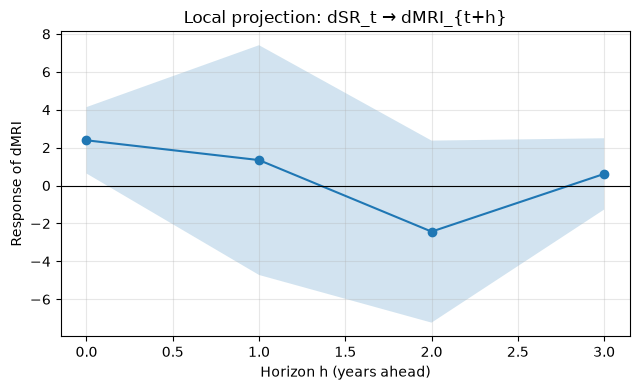

Cell 6 done.


In [7]:
# Phase 21 – Cell 6: Local projections IRF-style

from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase21" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase21" / "figures"
panel = pd.read_pickle(PROJECT / "outputs" / "phase21" / "data" / "phase21_sr_mri_panel.pkl").copy()
panel = panel.sort_values(["country", "year"])
panel["dSR"] = panel.groupby("country")["SR"].diff()
panel["dMRI"] = panel.groupby("country")["MRI"].diff()

print("=" * 60)
print("Phase 21 – Cell 6: Local projections")
print("=" * 60)

H = 3
rows = []
for h in range(0, H + 1):
    tmp = panel.copy()
    tmp["y_h"] = tmp.groupby("country")["dMRI"].shift(-h)  # future dMRI
    tmp["x"] = tmp["dSR"]
    tmp["y_l1"] = tmp.groupby("country")["dMRI"].shift(1)
    d = tmp.dropna(subset=["y_h", "x", "y_l1"])
    # country demean simple FE
    d["y_h"] = d["y_h"] - d.groupby("country")["y_h"].transform("mean")
    d["x"] = d["x"] - d.groupby("country")["x"].transform("mean")
    d["y_l1"] = d["y_l1"] - d.groupby("country")["y_l1"].transform("mean")
    X = sm.add_constant(d[["x", "y_l1"]])
    m = sm.OLS(d["y_h"], X).fit(cov_type="HC1")
    rows.append({
        "horizon": h,
        "coef_dSR": float(m.params["x"]),
        "se": float(m.bse["x"]),
        "pval": float(m.pvalues["x"]),
        "n": int(m.nobs),
    })
lp = pd.DataFrame(rows)
lp["ci_low"] = lp["coef_dSR"] - 1.96 * lp["se"]
lp["ci_high"] = lp["coef_dSR"] + 1.96 * lp["se"]
lp.to_csv(OUT_TAB / "phase21_local_projection.csv", index=False)
print(lp)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(lp["horizon"], lp["coef_dSR"], "-o")
ax.fill_between(lp["horizon"], lp["ci_low"], lp["ci_high"], alpha=0.2)
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("Horizon h (years ahead)")
ax.set_ylabel("Response of dMRI")
ax.set_title("Local projection: dSR_t → dMRI_{t+h}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase21_local_projection.png", dpi=150)
plt.show()
print("Cell 6 done.")

In [8]:
# Phase 21 – Cell 7: Quasi-experiment within country (high vs low dSR)

from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase21" / "tables"
panel = pd.read_pickle(PROJECT / "outputs" / "phase21" / "data" / "phase21_sr_mri_panel.pkl").copy()
panel = panel.sort_values(["country", "year"])
panel["dSR"] = panel.groupby("country")["SR"].diff()
panel["dMRI"] = panel.groupby("country")["MRI"].diff()
d = panel.dropna(subset=["dSR", "dMRI"]).copy()

print("=" * 60)
print("Phase 21 – Cell 7: Quasi-experiment high vs low dSR")
print("=" * 60)

# within-country: years with dSR above country median = treated
d["treat"] = d.groupby("country")["dSR"].transform(lambda s: (s >= s.median()).astype(int))
# outcome = dMRI
# country FE via demean
d["dMRI_dm"] = d["dMRI"] - d.groupby("country")["dMRI"].transform("mean")
d["treat_dm"] = d["treat"] - d.groupby("country")["treat"].transform("mean")
X = sm.add_constant(d[["treat_dm"]])
m = sm.OLS(d["dMRI_dm"], X).fit(cov_type="HC1")
print(m.summary().tables[1])

# simple group contrast
a = d.loc[d.treat == 1, "dMRI"].values
b = d.loc[d.treat == 0, "dMRI"].values
tt = stats.ttest_ind(a, b, equal_var=False)
mw = stats.mannwhitneyu(a, b, alternative="two-sided")

out = pd.DataFrame([{
    "mean_dMRI_high_dSR": float(np.mean(a)),
    "mean_dMRI_low_dSR": float(np.mean(b)),
    "diff": float(np.mean(a) - np.mean(b)),
    "ttest_p": float(tt.pvalue),
    "mannwhitney_p": float(mw.pvalue),
    "fe_treat_coef": float(m.params["treat_dm"]),
    "fe_treat_p": float(m.pvalues["treat_dm"]),
}])
out.to_csv(OUT_TAB / "phase21_quasiexperiment_dsr.csv", index=False)
print(out)
print("Cell 7 done.")
print("PHASE 21 STRENGTHENED.")

Phase 21 – Cell 7: Quasi-experiment high vs low dSR
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.388e-17      0.020  -6.78e-16      1.000      -0.040       0.040
treat_dm       0.1468      0.041      3.584      0.000       0.067       0.227
   mean_dMRI_high_dSR  mean_dMRI_low_dSR      diff   ttest_p  mannwhitney_p  \
0            0.075153          -0.071629  0.146783  0.000387       0.001015   

   fe_treat_coef  fe_treat_p  
0       0.146783    0.000338  
Cell 7 done.
PHASE 21 STRENGTHENED.
